# Harpy - Xenium - Introduction

In this series of notebooks, we will analyze a 10X Genomics [Xenium](https://www.10xgenomics.com/platforms/xenium) dataset using the [Harpy](https://harpy.readthedocs.io/en/latest/) package. Harpy is a Python package that allows flexible, modular and scalable analysis of spatial omics datasets. The package includes tools for image processing, segmentation, transcript allocation, feature extraction, and cell type annotation. We will also explore the Xenium dataset itself, introduce the SpatialData data format and how you can plot spatial data, and go over some additional analysis options, including segmentation-free approaches and downstream analysis steps.

When you make use of Harpy for analysis of spatial transcriptomics data, please cite [Pollaris et al. (2024)](https://www.biorxiv.org/content/biorxiv/early/2024/07/06/2024.07.04.601829.full.pdf) and [Rombaut et al. (2026)](https://academic.oup.com/bioinformatics/article/42/3/btag122/8519620?login=false).

Below, we analyze a 4,000 × 4,000 pixel subset of this dataset.

For a a compact end-to-end analysis of a 10,000 × 10,000 pixel subset of this dataset, including segmentation, transcript allocation, and basic downstream analysis see [this tutorial](https://harpy.readthedocs.io/en/latest/tutorials/general/Harpy_xenium_transcriptomics_subset.html).

For results on the complete dataset see [this tutorial](https://harpy.readthedocs.io/en/latest/tutorials/advanced/Harpy_transcriptomics_xenium.html).

## Import packages

In [1]:
import os

import dask.array as da
import harpy as hp
import matplotlib.pyplot as plt
import spatialdata as sd
import spatialdata_plot
import cellpose
import instanseg
import dask
import napari

_ = spatialdata_plot

assert hp.__version__ == "0.4.1"
assert sd.__version__ == "0.7.2"
assert cellpose.version == "3.1.1.3"
assert dask.__version__ == "2026.1.1"
assert napari.__version__ == "0.7.0"

## 1. Xenium Ovarian Cancer dataset
The dataset was made publically available by 10X Genomics: [FFPE Human Ovarian Cancer with 5K Human Pan Tissue and Pathways Panel plus 100 Custom Genes](https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-ovarian-cancer). Using this link, you could download the Xenium Onboard Analysis output folder to explore the files and start the analysis from these output files. However, in these training notebooks, we will instead download the data from our own registry using the code below.

A single-cell RNA sequencing dataset on a consecutive section was also made available: [Human Ovarian Cancer FFPE Single Cell Gene Expression Flex (Next GEM)](https://www.10xgenomics.com/datasets/17k-human-ovarian-cancer-scFFPE). Additionally, an analysis guide from 10X Genomics on how to use this scRNA-seq reference to annotate cell types in the Xenium dataset using Seurat can be found [here](https://www.10xgenomics.com/analysis-guides/xenium-cell-type-annotation).

A good first step is to have a look at the Xenium Analysis Summary from Xenium Onboard Analysis, which can be found [here](https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_analysis_summary.html) and can be used for an initial QC of the output data. Next, we would recommend to interactively explore the data using [Xenium Explorer](https://www.10xgenomics.com/support/software/xenium-explorer/latest). For this, we would need to locate the experiment.xenium file in the Xenium Onboard Analysis output folder and make sure the software is installed. In the case of this public dataset, we can also just open the [web demo](https://xenium.10xgenomics.com/?image=s3%2F10x.files%2Fxenium%2Fpreview%2FXenium_Prime_Ovarian_Cancer_FFPE_boosted%2Fexperiment.xenium&layers=cell~image~feature&cell_bt=cell&cell_c=groups&cell_g=10&cell_o=0.8&ct_c=Viridis&ct_o=0.8&ct_s=1_1276&cell_v=filled&z=14&off=&mi_v=true&axes=false&highlight=true&nav=true&rotation=0&target=32400.03_19524.55&tt_off=false&zoom=0.0179&feature=icon&feature_psc=6&feature_ps=circles&feature_off=0_188~190_220~222_349~351_421~423_765~767_806~808_1285~1287_1594~1596_2866~2868_3406~3408_4149~4151_4204~4206_4391~4393_4678~4680_4687~4689_4710~4712_4739~4741_4824~4826_4847~4849_9475&bin=10&d_c=Inferno&d_o=0.8&ii_minmax=__&ii_colors=_&ii_gamma=_&ii_b=0_0&ii_c=1_1&ii_n=H%26E%20Image%09H%26E%20Annotated%20Image&ii_o=1_1&ii_p=s3%2F10x.files%2Fxenium%2Fpreview%2FXenium_Prime_Ovarian_Cancer_FFPE_boosted%2Fhe_image.ome.tif%09s3%2F10x.files%2Fxenium%2Fpreview%2FXenium_Prime_Ovarian_Cancer_FFPE_boosted%2Fhe_annotated_image.ome.tif&ii_t=kzyedFNXhj8hKR3b5KH0P4DrlUUPiIbAISkd2%2BSh9L%2BTPJ50U1eGP8PfKbFV3uJAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAPA%2F_kzyedFNXhj8hKR3b5KH0P4DrlUUPiIbAISkd2%2BSh9L%2BTPJ50U1eGP8PfKbFV3uJAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAPA%2F&ii_v=false_false).

More information about Xenium can be found here:
- [Xenium Analyzer](https://www.10xgenomics.com/instruments/xenium-analyzer)
- [Xenium Onboard Analysis](https://www.10xgenomics.com/support/software/xenium-onboard-analysis/latest)
- [Xenium Explorer](https://www.10xgenomics.com/support/software/xenium-explorer/latest)
- [Gene panels](https://www.10xgenomics.com/products/xenium-panels#overview)
- [Xenium Prime 5K (Tech note)](https://cdn.10xgenomics.com/image/upload/v1721239182/support-documents/CG000775_Prime5K_DataHighlightsTN_RevA_updated.pdf)
- [Multimodal Cell Segmentation (Tech note)](https://cdn.10xgenomics.com/image/upload/v1754601291/support-documents/CG000750_XeniumInSitu_CellSegmentation_TechNote_RevB.pdf).

## 2. Create SpatialData
In the case of Xenium data, Harpy contains a convenient [reader function](https://harpy.readthedocs.io/en/latest/generated/harpy.io.xenium.html#harpy.io.xenium) to read in the images, transcripts, segmentation masks and tables into a SpatialData object, which can be backed to a Zarr store. In this notebook, we will download the already created SpatialData object, which was cropped to a 4000 x 4000 region of interest, from our registry.

Note that Harpy has a similar reader function for Vizgen MERSCOPE datasets (`hp.io.merscope`) and that other imaging-based spatial transcriptomics datasets can be read using a combination of more general functions ( `hp.im.add_image`, `hp.im.add_labels`, `hp.pt.add_points`, `hp.io.read_transcripts`,...). See the [documentation of Harpy](https://harpy.readthedocs.io/en/latest/index.html) for more details.

In [ ]:
import os
import sys
import tempfile
from pathlib import Path

import harpy as hp

from spatialdata import read_zarr

from summer_school_datasets import xenium_human_ovarian_cancer_course

if sys.platform == "win32":
    # Force short paths to avoid running into Windows limitation with path > 260 characters.
    temp_dir = "c:\\tmp"
    course_data_cache_path = "c:\\hp_cache"
    os.makedirs(temp_dir, exist_ok=True)
else:
    temp_dir = None  # use OS default
    course_data_cache_path = None  # use OS default

tmp = tempfile.TemporaryDirectory(dir=temp_dir, prefix="xenium_")
output_dir = Path(tmp.name)

sdata = xenium_human_ovarian_cancer_course(
    checkpoint="checkpoint_1",
    path=course_data_cache_path,
)

sdata.write(output_dir / "sdata.zarr", overwrite=True)

sdata = read_zarr(sdata.path)

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 auto

/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/dask/dataframe/io/parquet/arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Identity is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/rasterio/features.py:148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  yield from _shapes(source, mask, connectivity, transform)


In [3]:
sdata["table_global"].obs.index.name = "cells"

In [4]:
sdata["table_global"].obs

sdata = hp.tb.add_table(
    sdata,
    adata=sdata["table_global"].copy(),
    output_table_name="table_global",
    region=["cell_labels_global"],
    instance_key="cell_ID",
    region_key="fov_labels",
    overwrite=True,
)

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 auto

In [5]:
sdata = read_zarr("/Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr")

no parent found for <ome_zarr.reader.Label object at 0x132b058b0>: None
no parent found for <ome_zarr.reader.Label object at 0x132b07bf0>: None
no parent found for <ome_zarr.reader.Label object at 0x132f87dd0>: None


In [6]:
from harpy.datasets.registry import _calculate_sha256


_calculate_sha256("/Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr.zip")

'3d41c87a01673abf468ea662f4b34ca40909ff69a746149204ea0f17e15bf351'

In [7]:
from spatialdata import read_zarr

sdata = read_zarr("/Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr")
sdata["table_global"].obs.head()

no parent found for <ome_zarr.reader.Label object at 0x132093a40>: None
no parent found for <ome_zarr.reader.Label object at 0x13330fa40>: None
no parent found for <ome_zarr.reader.Label object at 0x132a717f0>: None


,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,fov_labels,z_level,cell_ID
cells,,,,,,,,,,,,,,
36736,102,0,0,0,0,20,122,53.058596,29.261251,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36736
36755,1023,0,0,0,0,115,1138,162.427037,122.147661,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36755
36756,341,0,0,0,0,34,375,47.459220,29.622501,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36756
36757,540,0,0,0,0,70,610,86.519378,67.418284,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36757
36762,435,0,0,0,0,5,440,58.522502,41.905002,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36762


## 3. Explore SpatialData
We can now explore the SpatialData object and the different layers contained within it. We will also have a look at some basic operations with SpatialData (reading, writing, adding, deleting, plotting, ...). More information about SpatialData can be found [here](https://spatialdata.scverse.org/en/stable/).

### 3.1 SpatialData

#### 3.1.1 Inspect contents in memory and on disk

In [8]:
# Check if SpatialData is backed (i.e. Zarr store on disk)
print("SpatialData backed by a Zarr store:", sdata.is_backed())
print("Path to associated Zarr store:", sdata.path)

SpatialData backed by a Zarr store: True
Path to associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr


In [9]:
# Check contents of Zarr store
print(f"Content of {sdata.path}:")
! ls -l {sdata.path} # On windows, use 'dir' instead of 'ls -l'

Content of /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr:
total 952
drwxr-xr-x@  9 arne.defauw  staff     288 Jun 11 13:50 images
drwxr-xr-x@  8 arne.defauw  staff     256 Jun 11 13:50 labels
drwxr-xr-x@  4 arne.defauw  staff     128 Jun 11 13:50 points
drwxr-xr-x@ 13 arne.defauw  staff     416 Jun 11 13:50 shapes
drwxr-xr-x@  6 arne.defauw  staff     192 Jun 11 13:50 tables
-rw-r--r--@  1 arne.defauw  staff  484654 Jun 11 13:50 zarr.json


In [10]:
# Check contents of images directory in Zarr store
images_dir = os.path.join(sdata.path, "images")
print(f"Content of {images_dir}:")
! ls -l {images_dir} # On windows, use 'dir' instead of 'ls -l'

Content of /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr/images:
total 8
drwxr-xr-x@  8 arne.defauw  staff  256 Jun 11 13:50 clahe
drwxr-xr-x@  4 arne.defauw  staff  128 Jun 11 13:50 dummy_image
drwxr-xr-x@ 10 arne.defauw  staff  320 Jun 11 13:50 he_image_global
drwxr-xr-x@  4 arne.defauw  staff  128 Jun 11 13:50 min_max_filtered
drwxr-xr-x@ 10 arne.defauw  staff  320 Jun 11 13:50 morphology_focus_global
drwxr-xr-x@  4 arne.defauw  staff  128 Jun 11 13:50 transcript_density
-rw-r--r--@  1 arne.defauw  staff   66 Jun 11 13:50 zarr.json


#### 3.1.2 Read and write SpatialData

In [11]:
# Write the SpatialData to Zarr (if not backed, but it should be backed by hp.io.xenium, or in our case hp.datasets.xenium_human_ovarian_cancer)

# sdata.write(sdata.path)

# NOTE: Notice that it will not allow you to overwrite an existing Zarr store ("The Zarr store already exists.")

In [12]:
# We can read in a preexisting Spatialdata (e.g. when coming back to an analysis if the SpatialData is no longer in memory)
sdata = sd.read_zarr(sdata.path)
sdata

no parent found for <ome_zarr.reader.Label object at 0x133933d10>: None
no parent found for <ome_zarr.reader.Label object at 0x133358ef0>: None
no parent found for <ome_zarr.reader.Label object at 0x1331a8c80>: None


SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250)
│     ├── 'dummy_image': DataArray[cyx] (4, 4000, 4000)
│     ├── 'he_image_global': DataTree[cyx] (3, 3128, 3128), (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 195, 195), (3, 97, 97), (3, 48, 48)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 4000, 4000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 62, 62)
│     └── 'transcript_density': DataArray[cyx] (1, 4000, 4000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (4000, 4000), (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125), (62, 62)
│     ├── 'cell_segmentation_mask': DataArray[yx] (1000, 1000)
│     ├── 'nucleus_labels_global': DataTree[yx] (4000, 4000), (2000,

#### 3.1.3 Subsetting, copying and removing SpatialData and spatial elements

In [13]:
# We can crop the SpatialData using a bounding box query
xmin = 12000
xmax = 13000
ymin = 21000
ymax = 22000

test_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[xmin, ymin],
    max_coordinate=[xmax, ymax],
    target_coordinate_system="global",
)

test_sdata

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 63, 63)
│     ├── 'dummy_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'he_image_global': DataTree[cyx] (3, 781, 782), (3, 391, 391), (3, 195, 196), (3, 98, 97), (3, 49, 49), (3, 24, 24), (3, 12, 12)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 1000, 1000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 63, 63), (4, 31, 31), (4, 16, 16)
│     └── 'transcript_density': DataArray[cyx] (1, 1000, 1000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (1000, 1000), (500, 500), (250, 250), (125, 125), (63, 63), (31, 31), (16, 16)
│     ├── 'cell_segmentation_mask': DataArray[yx] (1000, 1000)
│     ├── 'nucleus_labels_global': DataTree[yx] (1000, 1000), (500, 500), (250, 250), (125, 125), (63, 63), (31, 31), (16, 16)
│     ├── 'nucleus_segmentation_mask': DataArray[yx] (1000, 1000)
│ 

In [14]:
# We can check whether the cropped SpatialData is backed by a Zarr store
test_sdata.is_backed()

False

In [15]:
# Next, we write the cropped SpatialData to disk
test_sdata.write(os.path.join(output_dir, "test_sdata.zarr"))

/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Identity is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch6

In [16]:
test_sdata  # -> Not self contained, let's read back from the zarr store

SpatialData object, with associated Zarr store: /private/var/folders/sz/t3tgg4fs4tz9btm0fbqg_tzc0000gn/T/xenium_csc3sftj/test_sdata.zarr
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 63, 63)
│     ├── 'dummy_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'he_image_global': DataTree[cyx] (3, 781, 782), (3, 391, 391), (3, 195, 196), (3, 98, 97), (3, 49, 49), (3, 24, 24), (3, 12, 12)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 1000, 1000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 63, 63), (4, 31, 31), (4, 16, 16)
│     └── 'transcript_density': DataArray[cyx] (1, 1000, 1000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (1000, 1000), (500, 500), (250, 250), (125, 125), (63, 63), (31, 31), (16, 16)
│     ├── 'cell_segmentation_mask': DataArray[yx] (1000, 1000)
│     ├── 'nucleus_labels_global': DataTree[yx] (1000, 1000), (500, 500), (25

In [17]:
from spatialdata import read_zarr

test_sdata = read_zarr(test_sdata.path)
test_sdata  # -> Everything ok!

no parent found for <ome_zarr.reader.Label object at 0x1348304a0>: None
no parent found for <ome_zarr.reader.Label object at 0x134620590>: None
no parent found for <ome_zarr.reader.Label object at 0x134812c00>: None


SpatialData object, with associated Zarr store: /private/var/folders/sz/t3tgg4fs4tz9btm0fbqg_tzc0000gn/T/xenium_csc3sftj/test_sdata.zarr
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 63, 63)
│     ├── 'dummy_image': DataArray[cyx] (4, 1000, 1000)
│     ├── 'he_image_global': DataTree[cyx] (3, 781, 782), (3, 391, 391), (3, 195, 196), (3, 98, 97), (3, 49, 49), (3, 24, 24), (3, 12, 12)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 1000, 1000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 63, 63), (4, 31, 31), (4, 16, 16)
│     └── 'transcript_density': DataArray[cyx] (1, 1000, 1000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (1000, 1000), (500, 500), (250, 250), (125, 125), (63, 63), (31, 31), (16, 16)
│     ├── 'cell_segmentation_mask': DataArray[yx] (1000, 1000)
│     ├── 'nucleus_labels_global': DataTree[yx] (1000, 1000), (500, 500), (25

In [18]:
# To remove the cropped SpatialData from disk, we could simply navigate to the Zarr store and remove it from our file system. We can also remove it in the notebook itself using shutil.
import shutil

shutil.rmtree(test_sdata.path)  # Removes SpatialData from disk
del test_sdata  # Removes SpatialData from memory

In [19]:
# Copy a spatial element:
sdata["copy"] = sdata["morphology_focus_global"]
sdata.write_element("copy")

sdata = sd.read_zarr(sdata.path)  # If we do not read back, the spatialdata zarr store will not be 'self-contained'.
sdata

# NOTE: we discourage the use of spatialdata.deepcopy(), because it will load large Dask-backed objects in memory.

no parent found for <ome_zarr.reader.Label object at 0x1343f78c0>: None
no parent found for <ome_zarr.reader.Label object at 0x134486d50>: None
no parent found for <ome_zarr.reader.Label object at 0x134434dd0>: None


SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250)
│     ├── 'copy': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 62, 62)
│     ├── 'dummy_image': DataArray[cyx] (4, 4000, 4000)
│     ├── 'he_image_global': DataTree[cyx] (3, 3128, 3128), (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 195, 195), (3, 97, 97), (3, 48, 48)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 4000, 4000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 62, 62)
│     └── 'transcript_density': DataArray[cyx] (1, 4000, 4000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (4000, 4000), (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125), 

In [20]:
# To remove a spatial element, we can use `del`
del sdata.images[
    "copy"
]  # This deletes the element from memory, but does not remove the corresponding directory in the Zarr store.
sdata

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250)
│     ├── 'dummy_image': DataArray[cyx] (4, 4000, 4000)
│     ├── 'he_image_global': DataTree[cyx] (3, 3128, 3128), (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 195, 195), (3, 97, 97), (3, 48, 48)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 4000, 4000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 62, 62)
│     └── 'transcript_density': DataArray[cyx] (1, 4000, 4000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (4000, 4000), (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125), (62, 62)
│     ├── 'cell_segmentation_mask': DataArray[yx] (1000, 1000)
│     ├── 'nucleus_labels_global': DataTree[yx] (4000, 4000), (2000,

In [21]:
# If we read in the cropped SpatialData, we can see the spatial element is still there
sdata = sd.read_zarr(sdata.path)
sdata

no parent found for <ome_zarr.reader.Label object at 0x13388b350>: None
no parent found for <ome_zarr.reader.Label object at 0x134c7fce0>: None
no parent found for <ome_zarr.reader.Label object at 0x134620bf0>: None


SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250)
│     ├── 'copy': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 62, 62)
│     ├── 'dummy_image': DataArray[cyx] (4, 4000, 4000)
│     ├── 'he_image_global': DataTree[cyx] (3, 3128, 3128), (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 195, 195), (3, 97, 97), (3, 48, 48)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 4000, 4000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 62, 62)
│     └── 'transcript_density': DataArray[cyx] (1, 4000, 4000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (4000, 4000), (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125), 

In [22]:
# To remove an element completely, we should use both 'del' and 'delete_element_from_disk'
del sdata.images["copy"]
sdata.delete_element_from_disk("copy")

# Read back SpatialData
sdata = sd.read_zarr(sdata.path)
sdata

no parent found for <ome_zarr.reader.Label object at 0x13471bda0>: None
no parent found for <ome_zarr.reader.Label object at 0x13554c080>: None
no parent found for <ome_zarr.reader.Label object at 0x13386deb0>: None


SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250)
│     ├── 'dummy_image': DataArray[cyx] (4, 4000, 4000)
│     ├── 'he_image_global': DataTree[cyx] (3, 3128, 3128), (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 195, 195), (3, 97, 97), (3, 48, 48)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 4000, 4000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 62, 62)
│     └── 'transcript_density': DataArray[cyx] (1, 4000, 4000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (4000, 4000), (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125), (62, 62)
│     ├── 'cell_segmentation_mask': DataArray[yx] (1000, 1000)
│     ├── 'nucleus_labels_global': DataTree[yx] (4000, 4000), (2000,

#### 3.1.4 Coordinate systems and transformations
All elements in a `SpatialData` object are assigned to one or more coordinate systems, which allows for storing multiple samples in the same `SpatialData` object (e.g. each in their own coordinate system). Transformations between spatial elements make sure they allow align with the coordinate systems.

Some common transformations are:
- Identity
- Translation
- Scale
- Sequence
- Affine
- ...

We refer to these tutorials for more information:
-  [Tutorial Harpy](https://harpy.readthedocs.io/en/latest/tutorials/advanced/coordinate_systems.html)
-  [Tutorial SpatialData](https://spatialdata.scverse.org/en/stable/tutorials/notebooks/notebooks/examples/transformations.html)

In [23]:
# Inspect SpatialData to see coordinate systems
sdata

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250)
│     ├── 'dummy_image': DataArray[cyx] (4, 4000, 4000)
│     ├── 'he_image_global': DataTree[cyx] (3, 3128, 3128), (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 195, 195), (3, 97, 97), (3, 48, 48)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 4000, 4000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 62, 62)
│     └── 'transcript_density': DataArray[cyx] (1, 4000, 4000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (4000, 4000), (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125), (62, 62)
│     ├── 'cell_segmentation_mask': DataArray[yx] (1000, 1000)
│     ├── 'nucleus_labels_global': DataTree[yx] (4000, 4000), (2000,

In [24]:
# Inspect coordinate systems and transformations associated with specific spatial elements
from spatialdata.transformations import (
    Identity,
    get_transformation,
    remove_transformation,
    set_transformation,
)

get_transformation(sdata.images["morphology_focus_global"], get_all=True)

{'global': Sequence 
     Translation (c, y, x)
         [   0. 3000. 2000.]
     Sequence 
         Translation (c, y, x)
             [    0. 18000. 10000.]
         Identity ,
 'global_micron': Sequence 
     Translation (c, y, x)
         [   0. 3000. 2000.]
     Sequence 
         Translation (c, y, x)
             [    0. 18000. 10000.]
         Sequence 
             Identity 
             Scale (c, y, x)
                 [1.     0.2125 0.2125]}

In [25]:
# Let's create a new coordinate system
transformations = get_transformation(sdata.images["morphology_focus_global"], get_all=True)

transformations["new_coordinate_system"] = Identity()

set_transformation(
    sdata["morphology_focus_global"],
    transformation=transformations,
    set_all=True,
    write_to_sdata=sdata,
)
sdata

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250)
│     ├── 'dummy_image': DataArray[cyx] (4, 4000, 4000)
│     ├── 'he_image_global': DataTree[cyx] (3, 3128, 3128), (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 195, 195), (3, 97, 97), (3, 48, 48)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 4000, 4000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 62, 62)
│     └── 'transcript_density': DataArray[cyx] (1, 4000, 4000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (4000, 4000), (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125), (62, 62)
│     ├── 'cell_segmentation_mask': DataArray[yx] (1000, 1000)
│     ├── 'nucleus_labels_global': DataTree[yx] (4000, 4000), (2000,

In [26]:
get_transformation(sdata.images["morphology_focus_global"], get_all=True)

{'global': Sequence 
     Translation (c, y, x)
         [   0. 3000. 2000.]
     Sequence 
         Translation (c, y, x)
             [    0. 18000. 10000.]
         Identity ,
 'global_micron': Sequence 
     Translation (c, y, x)
         [   0. 3000. 2000.]
     Sequence 
         Translation (c, y, x)
             [    0. 18000. 10000.]
         Sequence 
             Identity 
             Scale (c, y, x)
                 [1.     0.2125 0.2125],
 'new_coordinate_system': Identity }

In [27]:
# We can now remove the coordinate system again
remove_transformation(
    sdata["morphology_focus_global"],
    to_coordinate_system="new_coordinate_system",
    write_to_sdata=sdata,
)

get_transformation(sdata.images["morphology_focus_global"], get_all=True)

{'global': Sequence 
     Translation (c, y, x)
         [   0. 3000. 2000.]
     Sequence 
         Translation (c, y, x)
             [    0. 18000. 10000.]
         Identity ,
 'global_micron': Sequence 
     Translation (c, y, x)
         [   0. 3000. 2000.]
     Sequence 
         Translation (c, y, x)
             [    0. 18000. 10000.]
         Sequence 
             Identity 
             Scale (c, y, x)
                 [1.     0.2125 0.2125]}

#### 3.1.5 Exploring Spatialdata interactively in Napari

In [28]:
# Interactively plot SpatialData in Napari
from napari_harpy import Interactive

# do a new pip install of napari harpy, also rechunk the data, add more scales (finer scales)

Interactive(sdata, widgets="viewer")

### 3.2 Elements
Images, Labels and Points are lazy if the `SpatialData` object is backed by a `.zarr` store. Lazy means they will not be 'pulled' into RAM, unless you ask for it (e.g. calling `.compute()`, `.persist()` on the Dask objects).

[Dask](https://www.dask.org/) enables out-of-core computation, allowing you to process datasets that exceed the available RAM, and also facilitates parallelized computations.

Note that currently Tables and Shapes are not lazy, and will be loaded into memory when you load a `SpatialData` object. In the future, shapes will probably also be lazy, https://github.com/scverse/spatialdata/issues/359.

Support for lazy Tables should also be coming soon in `SpatialData`, but note that there is limited `Dask` support in e.g. `Scanpy` https://scanpy-tutorials.readthedocs.io/en/latest/dask.html, which would mean Tables need to be pulled in memory when `Scanpy` functions are applied on it.

In [29]:
# Let's return to our Spatial Data object and inspect which layers it contains
sdata

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_xe_11_6_2.zarr
├── Images
│     ├── 'clahe': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250)
│     ├── 'dummy_image': DataArray[cyx] (4, 4000, 4000)
│     ├── 'he_image_global': DataTree[cyx] (3, 3128, 3128), (3, 1564, 1564), (3, 782, 782), (3, 391, 391), (3, 195, 195), (3, 97, 97), (3, 48, 48)
│     ├── 'min_max_filtered': DataArray[cyx] (4, 4000, 4000)
│     ├── 'morphology_focus_global': DataTree[cyx] (4, 4000, 4000), (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125), (4, 62, 62)
│     └── 'transcript_density': DataArray[cyx] (1, 4000, 4000)
├── Labels
│     ├── 'cell_labels_global': DataTree[yx] (4000, 4000), (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125), (62, 62)
│     ├── 'cell_segmentation_mask': DataArray[yx] (1000, 1000)
│     ├── 'nucleus_labels_global': DataTree[yx] (4000, 4000), (2000,

#### 3.2.1 Images

In [30]:
# Inspect image layer
sdata.images["morphology_focus_global"]  # This is a multiscale image so it is an xarray.DataTree

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 4, y: 4000, x: 4000)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 32kB 0.5 1.5 2.5 3.5 ... 3.998e+03 3.998e+03 4e+03
│         * x        (x) float64 32kB 0.5 1.5 2.5 3.5 ... 3.998e+03 3.998e+03 4e+03
│       Data variables:
│           image    (c, y, x) uint16 128MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 4, y: 2000, x: 2000)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 16kB 1.0 3.0 5.0 7.0 ... 3.995e+03 3.997e+03 3.999e+03
│         * x        (x) float64 16kB 1.0 3.0 5.0 7.0 ... 3.995e+03 3.997e+03 3.999e+03
│       Data variables:
│           image    (c, y, x) uint16 32MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 4, y: 1000, x: 1000)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 8kB 2.0 6.0 10.0 14.0 ... 3.99e+03 3.994e+03 3.998e+03
│         * x        (x) float64 8kB 2.0 6.0 10.0 14.0 ... 3.99e+03 3.994e+03 3.998e+03
│       Data variables:
│           image    (c, y, x) uint16 8MB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (c: 4, y: 500, x: 500)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 4kB 4.0 12.0 20.0 28.0 ... 3.98e+03 3.988e+03 3.996e+03
│         * x        (x) float64 4kB 4.0 12.0 20.0 28.0 ... 3.98e+03 3.988e+03 3.996e+03
│       Data variables:
│           image    (c, y, x) uint16 2MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
├── Group: /scale4
│       Dimensions:  (c: 4, y: 250, x: 250)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 2kB 8.0 24.0 40.0 56.0 ... 3.96e+03 3.976e+03 3.992e+03
│         * x        (x) float64 2kB 8.0 24.0 40.0 56.0 ... 3.96e+03 3.976e+03 3.992e+03
│       Data variables:
│           image    (c, y, x) uint16 500kB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
├── Group: /scale5
│       Dimensions:  (c: 4, y: 125, x: 125)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 1kB 16.0 48.0 80.0 ... 3.92e+03 3.952e+03 3.984e+03
│         * x        (x) float64 1kB 16.0 48.0 80.0 ... 3.92e+03 3.952e+03 3.984e+03
│       Data variables:
│           image    (c, y, x) uint16 125kB dask.array<chunksize=(1, 125, 125), meta=np.ndarray>
└── Group: /scale6
        Dimensions:  (c: 4, y: 62, x: 62)
        Coordinates:
          * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
          * y        (y) float64 496B 32.26 96.77 161.3 ... 3.903e+03 3.968e+03
          * x        (x) float64 496B 32.26 96.77 161.3 ... 3.903e+03 3.968e+03
        Data variables:
            image    (c, y, x) uint16 31kB dask.array<chunksize=(1, 62, 62), meta=np.ndarray>

In [31]:
# Get spatial element using hp.im.get_dataarray
se = hp.im.get_dataarray(sdata, element_name="morphology_focus_global")  # Gets scale0 if it is a multiscale image
se  # This is an xarray.DataArray

<xarray.DataArray 'image' (c: 4, y: 4000, x: 4000)> Size: 128MB
dask.array<from-zarr, shape=(4, 4000, 4000), dtype=uint16, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
  * y        (y) float64 32kB 0.5 1.5 2.5 3.5 ... 3.998e+03 3.998e+03 4e+03
  * x        (x) float64 32kB 0.5 1.5 2.5 3.5 ... 3.998e+03 3.998e+03 4e+03
Attributes:
    transform:  {'global': Sequence \n    Translation (c, y, x)\n        [   ...

In [32]:
se.data  # This is a Dask array

dask.array<from-zarr, shape=(4, 4000, 4000), dtype=uint16, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>

In [33]:
# compute the image array
se.data.compute()  # This is a numpy array

array([[[ 498,  556,  676, ...,  192,  194,  211],
        [ 462,  577,  669, ...,  220,  202,  226],
        [ 454,  517,  642, ...,  224,  235,  264],
        ...,
        [ 170,  179,  167, ...,   83,   94,   85],
        [ 147,  153,  149, ...,   97,   87,   87],
        [ 150,  150,  143, ...,   90,   80,   84]],

       [[1746, 1917, 2114, ...,  819,  755,  730],
        [1596, 1821, 2042, ...,  838,  787,  758],
        [1439, 1637, 1814, ...,  861,  881,  856],
        ...,
        [ 219,  250,  233, ...,  174,  196,  173],
        [ 247,  251,  236, ...,  190,  203,  162],
        [ 289,  289,  282, ...,  178,  180,  208]],

       [[1678, 1657, 1693, ...,   49,   47,   44],
        [1658, 1626, 1640, ...,   48,   49,   64],
        [1595, 1553, 1528, ...,   39,   63,   68],
        ...,
        [  62,   64,   68, ...,   74,   71,   78],
        [  73,   71,   63, ...,   78,   87,   94],
        [  79,   72,   71, ...,   81,   97,  102]],

       [[  55,   79,   75, ...,  521,

In [34]:
# Inspect image dimensions
print("Image dimensions:", se.dims)  # Image layers have c,(z),y,x dimension. z dimension is optional
print("Image shape:", se.shape)

Image dimensions: ('c', 'y', 'x')
Image shape: (4, 4000, 4000)


In [35]:
# Inspect data type
print(
    "Image dtype:", se.data.dtype
)  # The data type of an image layer can be integer or float: uint8, uint16, float32, ...

Image dtype: uint16


In [36]:
# Inspect channel names
se.c.data

array(['DAPI', 'ATP1A1/CD45/E-Cadherin', '18S', 'AlphaSMA/Vimentin'],
      dtype='<U22')

#### 3.2.2 Labels
Labels layers typically represent segmentation masks.

Labels and images are sometimes referred to as `raster` data.

In [37]:
# Inspect labels layer
sdata.labels["nucleus_labels_global"]  # This is multiscale so it is a datatree.DataTree

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (y: 4000, x: 4000)
│       Coordinates:
│         * y        (y) float64 32kB 0.5 1.5 2.5 3.5 ... 3.998e+03 3.998e+03 4e+03
│         * x        (x) float64 32kB 0.5 1.5 2.5 3.5 ... 3.998e+03 3.998e+03 4e+03
│       Data variables:
│           image    (y, x) uint32 64MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (y: 2000, x: 2000)
│       Coordinates:
│         * y        (y) float64 16kB 1.0 3.0 5.0 7.0 ... 3.995e+03 3.997e+03 3.999e+03
│         * x        (x) float64 16kB 1.0 3.0 5.0 7.0 ... 3.995e+03 3.997e+03 3.999e+03
│       Data variables:
│           image    (y, x) uint32 16MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (y: 1000, x: 1000)
│       Coordinates:
│         * y        (y) float64 8kB 2.0 6.0 10.0 14.0 ... 3.99e+03 3.994e+03 3.998e+03
│         * x        (x) float64 8kB 2.0 6.0 10.0 14.0 ... 3.99e+03 3.994e+03 3.998e+03
│       Data variables:
│           image    (y, x) uint32 4MB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (y: 500, x: 500)
│       Coordinates:
│         * y        (y) float64 4kB 4.0 12.0 20.0 28.0 ... 3.98e+03 3.988e+03 3.996e+03
│         * x        (x) float64 4kB 4.0 12.0 20.0 28.0 ... 3.98e+03 3.988e+03 3.996e+03
│       Data variables:
│           image    (y, x) uint32 1MB dask.array<chunksize=(500, 500), meta=np.ndarray>
├── Group: /scale4
│       Dimensions:  (y: 250, x: 250)
│       Coordinates:
│         * y        (y) float64 2kB 8.0 24.0 40.0 56.0 ... 3.96e+03 3.976e+03 3.992e+03
│         * x        (x) float64 2kB 8.0 24.0 40.0 56.0 ... 3.96e+03 3.976e+03 3.992e+03
│       Data variables:
│           image    (y, x) uint32 250kB dask.array<chunksize=(250, 250), meta=np.ndarray>
├── Group: /scale5
│       Dimensions:  (y: 125, x: 125)
│       Coordinates:
│         * y        (y) float64 1kB 16.0 48.0 80.0 ... 3.92e+03 3.952e+03 3.984e+03
│         * x        (x) float64 1kB 16.0 48.0 80.0 ... 3.92e+03 3.952e+03 3.984e+03
│       Data variables:
│           image    (y, x) uint32 62kB dask.array<chunksize=(125, 125), meta=np.ndarray>
└── Group: /scale6
        Dimensions:  (y: 62, x: 62)
        Coordinates:
          * y        (y) float64 496B 32.26 96.77 161.3 ... 3.903e+03 3.968e+03
          * x        (x) float64 496B 32.26 96.77 161.3 ... 3.903e+03 3.968e+03
        Data variables:
            image    (y, x) uint32 15kB dask.array<chunksize=(62, 62), meta=np.ndarray>

In [38]:
# Inspect data type
se = hp.im.get_dataarray(sdata, element_name="nucleus_labels_global")  # This is an xarray.DataArray
se.dtype  # Data type of labels is always int (i.e.: float is not allowed).

dtype('<u4')

#### 3.2.3 Shapes
Shapes either represent the boundaries of a segmentation mask (e.g. cells), or region annotations (e.g. artifacts, tumor regions, ...). Shapes are of type GeoDataFrame. They can be manipulated using the [geopandas](https://geopandas.org/en/stable/) library. Shapes layers can be converted into labels layers by rasterization and labels layers can be converted into shapes layers by vectorization. When using `Harpy` to generate shapes (via e.g. `hp.im.segment` or `hp.sh.vectorize`), the index of the shapes layer holds the cell id (its name is 'cell_ID') and corresponds to the labels in the corresponding labels layer.

In [39]:
# Convert labels layers into shapes layers
sdata = hp.sh.vectorize(
    sdata,
    labels_name="nucleus_labels_global",
    output_shapes_name="nucleus_shapes_global",
    overwrite=True,
)

sdata = hp.sh.vectorize(
    sdata,
    labels_name="cell_labels_global",
    output_shapes_name="cell_shapes_global",
    overwrite=True,
)

# NOTE: `spatialdata` also implements vectorization (`spatialdata.to_polygons`) and rasterization (`spatialdata.rasterize`), but these implementations are slower, and require much more RAM.

2026-06-11 14:04:52.374 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:338 - Finished vectorizing. Dissolving shapes at the border of the chunks. This can take a couple minutes if input mask contains many chunks.
2026-06-11 14:04:52.468 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:344 - Dissolve is done.
2026-06-11 14:04:53.099 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'nucleus_shapes_global' already exists. Overwriting...
2026-06-11 14:04:54.223 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:338 - Finished vectorizing. Dissolving shapes at the border of the chunks. This can take a couple minutes if input mask contains many chunks.
2026-06-11 14:04:54.328 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:344 - Dissolve is done.
2026-06-11 14:04:54.761 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'cell_shapes_global' already exists. Overwriting...


In [40]:
# Inspect shapes layer
sdata.shapes["nucleus_shapes_global"].head()

,geometry
cell_ID,
39458,"POLYGON ((13 3715, 13 3716, 9 3716, 9 3717, 6 ..."
39476,"POLYGON ((3 1566, 3 1567, 2 1567, 2 1568, 1 15..."
39477,"POLYGON ((0 1555, 0 1563, 1 1563, 1 1555, 0 15..."
39482,"POLYGON ((5 1419, 5 1420, 2 1420, 2 1421, 1 14..."
39483,"POLYGON ((0 1384, 0 1412, 7 1412, 7 1411, 9 14..."


In [41]:
# Inspect data type
print(
    type(sdata.shapes["nucleus_shapes_global"])
)  # Shapes are of type GeoDataFrame and we can use geopandas to manipulate them.

<class 'geopandas.geodataframe.GeoDataFrame'>


In [42]:
# Inspect index
sdata.shapes["nucleus_shapes_global"].index.name

'cell_ID'

In [43]:
# Inspect geometry
sdata.shapes["nucleus_shapes_global"].geometry.head()

cell_ID
39458    POLYGON ((13 3715, 13 3716, 9 3716, 9 3717, 6 ...
39476    POLYGON ((3 1566, 3 1567, 2 1567, 2 1568, 1 15...
39477    POLYGON ((0 1555, 0 1563, 1 1563, 1 1555, 0 15...
39482    POLYGON ((5 1419, 5 1420, 2 1420, 2 1421, 1 14...
39483    POLYGON ((0 1384, 0 1412, 7 1412, 7 1411, 9 14...
Name: geometry, dtype: geometry

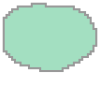

In [44]:
# Quickly plot geometry of nucleus 39458
sdata.shapes["nucleus_shapes_global"].geometry[39458]

In [45]:
# Convert shapes back to labels
se = hp.im.get_dataarray(sdata, element_name="nucleus_labels_global")

sdata = hp.im.rasterize(
    sdata,
    shapes_name="nucleus_shapes_global",
    output_labels_name="nucleus_labels_global_copy",
    out_shape=se.shape,
    chunks=5000,
    overwrite=True,
)

2026-06-11 14:04:55.548 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'nucleus_labels_global_copy'
no parent found for <ome_zarr.reader.Label object at 0x13555ed80>: None
no parent found for <ome_zarr.reader.Label object at 0x359427a70>: None
no parent found for <ome_zarr.reader.Label object at 0x358ad3ce0>: None
no parent found for <ome_zarr.reader.Label object at 0x359125be0>: None


<b>Excercise</b>:

- Are the labels layers `nucleus_labels_global` and `nucleus_labels_global_copy` equal? Do you expect them to be equal?

<details>
<summary>Click to reveal the solution</summary>

```python
se_1 = hp.im.get_dataarray(sdata, layer="nucleus_labels_global")
se_2 = hp.im.get_dataarray(sdata, layer="nucleus_labels_global_copy")

pixels_not_equal = (~ np.equal(se_2.data.compute(), se_1.data.compute())).sum() 

print(f"After roundtrip vectorization and rasterization, {pixels_not_equal} pixels are not equal.")

print("Number of cells in nucleus_labels_global:", len(da.unique(se_1.data).compute()))
print("Number of cells in nucleus_labels_global_copy:", len(da.unique(se_2.data).compute()))


<b>Excercise</b>:
- Remove the `nucleus_labels_global_copy` layer.

<details>
<summary>Click to reveal the solution</summary>

```python
del sdata.labels["nucleus_labels_global_copy"]
sdata.delete_element_from_disk("nucleus_labels_global_copy")

In [46]:
del sdata.labels["nucleus_labels_global_copy"]
sdata.delete_element_from_disk("nucleus_labels_global_copy")

#### 3.2.4 Points
Points are DaskDataFrame object (see https://docs.dask.org/en/stable/dataframe.html). Points represent the spatial location of a feature. In our case this will almost always be a gene.

In [47]:
# Inspect points layer
sdata.points["transcripts_global"]

,x,y,gene
npartitions=1,,,
,float64,float64,category[unknown]
,...,...,...


In [48]:
# Compute points layer as pandas dataframe
sdata.points["transcripts_global"].compute().head()  # This is a pandas.DataFrame

,x,y,gene
0,12979.852941,21162.500000,AAMP
1,12981.176471,21136.691176,AAMP
2,13007.794118,21047.132353,AAMP
3,13373.602941,21102.205882,AAMP
4,13427.573529,21135.000000,AAMP


<b>Excercise</b>:
- Use the points layer `transcripts_global` to determine how many unique genes were measured.

<details>
<summary>Click to reveal the solution</summary>

```python
sdata.points["transcripts_global"]["gene"].nunique().compute()

#### 3.2.5 Tables
Tables are [AnnData](https://anndata.readthedocs.io/en/latest/) objects. An `AnnData` object (`adata`) contains following attributes:

- `adata.X`: Main data matrix (observations x features). Observations are generally cells, while features (or variables) are generally genes.
- `adata.obs`: Metadata for each observation (e.g. QC-metrics, cell types, morphological characteristics).
- `adata.var`: Metadata for each feature (e.g. QC-metrics, gene ontology).
- `adata.uns`: Unstructured information (e.g. color schemes, settings).
- `adata.obsm`: Embeddings or reduced dimensions (e.g., PCA or UMAP coordinates, spatial coordinates).

In [49]:
# Inspect tables layer
sdata.tables["table_global"]

AnnData object with n_obs × n_vars = 6079 × 5101
    obs: 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'fov_labels', 'z_level', 'cell_ID'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

`adata.X`

- Data type is a sparse or dense NumPy array or SciPy sparse matrix.
- This is the core data matrix of the AnnData object, typically an m×n matrix, where m is the number of observations (cells), and n is the number of variables (genes).
- Stores the primary quantitative data for each cell/gene pair, such as raw counts, normalized expression values, or transformations of the raw quantifications.

In [50]:
# Inspect count matrix
sdata.tables["table_global"].X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1640504 stored elements and shape (6079, 5101)>

In [51]:
# Get shape of data matrix
sdata.tables["table_global"].X.shape

(6079, 5101)

In [52]:
# Get matrix as dataframe
sdata.tables["table_global"].to_df().head()  # Not recommended for large datasets

,A2ML1,AAMP,AAR2,AARSD1,ABAT,ABCA1,ABCA10,ABCA3,ABCA4,ABCA7,...,ZPR1,ZSCAN1,ZSCAN12,ZSCAN16,ZSCAN20,ZSCAN26,ZSWIM6,ZUP1,ZYG11B,ZYX
cells,,,,,,,,,,,,,,,,,,,,,
36736,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36755,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36756,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36757,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
36762,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


`adata.obs`

- Data type is a `pandas.DataFrame`.
- Each row corresponds to an observation in adata.X.
- Each colum corresponds to metadata about each observation: QC-metrics, cell types, clustering IDs, sample IDs, morphological features...

In [53]:
sdata.tables["table_global"].obs.head()

,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,fov_labels,z_level,cell_ID
cells,,,,,,,,,,,,,,
36736,102,0,0,0,0,20,122,53.058596,29.261251,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36736
36755,1023,0,0,0,0,115,1138,162.427037,122.147661,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36755
36756,341,0,0,0,0,34,375,47.459220,29.622501,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36756
36757,540,0,0,0,0,70,610,86.519378,67.418284,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36757
36762,435,0,0,0,0,5,440,58.522502,41.905002,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36762


In [54]:
# Inspect number of cells per segmentation method
sdata.tables["table_global"].obs["segmentation_method"].value_counts()

segmentation_method
Segmented by interior stain (18S)                       3340
Segmented by boundary stain (ATP1A1+CD45+E-Cadherin)    2516
Segmented by nucleus expansion of 5.0µm                  223
Name: count, dtype: int64

In [55]:
# Inspect number of nuclei per cell
sdata.tables["table_global"].obs["nucleus_count"].value_counts()

nucleus_count
1.0    5692
2.0     235
0.0     133
3.0      17
5.0       1
4.0       1
Name: count, dtype: int64

<Axes: >

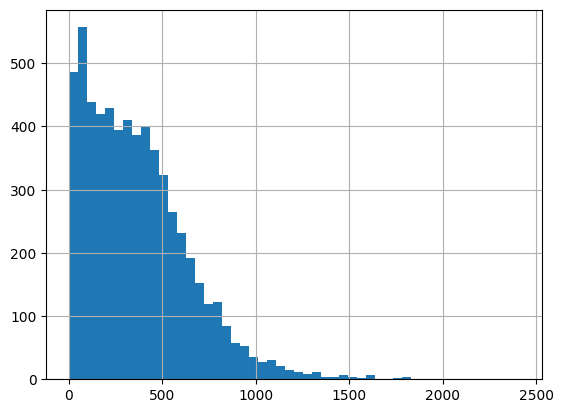

In [56]:
# Quick histogram of number of transcripts per cell
sdata.tables["table_global"].obs["transcript_counts"].hist(bins=50)

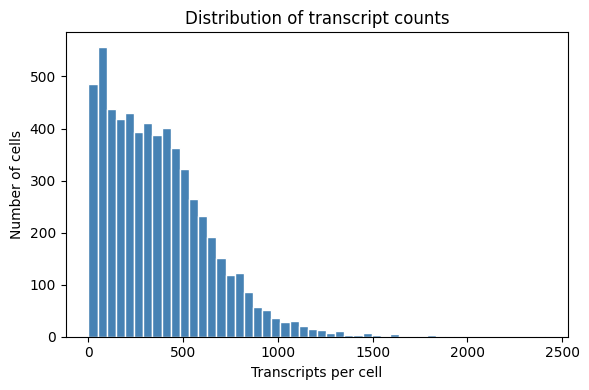

In [57]:
# Prettier histogram of number of transcripts per cell using matplotlib
ax = (
    sdata.tables["table_global"]
    .obs["transcript_counts"]
    .plot.hist(bins=50, figsize=(6, 4), edgecolor="white", color="steelblue")
)

ax.set_xlabel("Transcripts per cell")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of transcript counts")
plt.tight_layout()


`adata.var`

- Data type is a `pandas.DataFrame`.
- Each row corresponds to a feature in adata.X.
- Each colum corresponds to metadata about each feature: QC-metrics, gene ontology...

In [58]:
sdata.tables["table_global"].var.head()

,gene_ids,feature_types,genome
A2ML1,ENSG00000166535,Gene Expression,Unknown
AAMP,ENSG00000127837,Gene Expression,Unknown
AAR2,ENSG00000131043,Gene Expression,Unknown
AARSD1,ENSG00000266967,Gene Expression,Unknown
ABAT,ENSG00000183044,Gene Expression,Unknown


`adata.uns`

- `.uns` (unstructured data) is a dictionary for storing additional, often unstructured, information relevant to the dataset.
- Data type is a dictionary where you can store various data types, such as strings, arrays, or even nested dictionaries.
- Typically used for storing global dataset information, annotations, and visualization settings, like color palettes for clusters or parameter settings for computational methods

In [59]:
sdata.tables["table_global"].uns

{'spatialdata_attrs': {'region': ['cell_labels_global'],
  'region_key': 'fov_labels',
  'instance_key': 'cell_ID'}}

`adata.obsm`

- `.obsm` is a mapping of additional multi-dimensional arrays associated with each observation.
- Data type is a dictionary-like structure where each entry is typically a matrix or array of coordinates.
- Stores embeddings, dimensional reductions, spatial coordinates, or other coordinate-based data associated with observations.

In [60]:
sdata.tables["table_global"].obsm

AxisArrays with keys: spatial

In [61]:
sdata.tables["table_global"].obsm["spatial"][:5]  # Contains centroid coordinates of cells (in pixels!)

array([[12014.94829963, 24728.2421875 ],
       [11968.46162684, 22624.29227941],
       [12003.99471507, 22584.25551471],
       [11979.95174632, 22564.86443015],
       [12006.3292739 , 22439.52205882]])

`Region key` and `Instance key`

A table element can be annotated by any spatial element (`images`, `labels`, `shapes`, `points`) (using the API of Spatialdata), but tables generated by `Harpy` will be annotated by a `labels` element.

In [62]:
from spatialdata.models import TableModel

sdata.tables["table_global"].uns[TableModel.ATTRS_KEY]

{'region': ['cell_labels_global'],
 'region_key': 'fov_labels',
 'instance_key': 'cell_ID'}

In [63]:
from harpy.utils._keys import _INSTANCE_KEY, _REGION_KEY

print("Instance key column:", _INSTANCE_KEY)  # Column in .obs that will be used for cell_ID
print(
    "Region key column:", _REGION_KEY
)  # Column in .obs that will be used for linking AnnData object to spatial element (a labels layer, e.g. a segmentation mask).

Instance key column: cell_ID
Region key column: fov_labels


In [64]:
# Inspect instance and region keys in obs
sdata.tables["table_global"].obs.head()

,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,fov_labels,z_level,cell_ID
cells,,,,,,,,,,,,,,
36736,102,0,0,0,0,20,122,53.058596,29.261251,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36736
36755,1023,0,0,0,0,115,1138,162.427037,122.147661,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36755
36756,341,0,0,0,0,34,375,47.459220,29.622501,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36756
36757,540,0,0,0,0,70,610,86.519378,67.418284,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36757
36762,435,0,0,0,0,5,440,58.522502,41.905002,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_labels_global,0.0,36762


In [65]:
# Inspect instance key values in obs
sdata.tables["table_global"].obs[_INSTANCE_KEY].values[:5]

array([36736, 36755, 36756, 36757, 36762])

In [66]:
# Shapes index correspond to cell_ID values
sdata.shapes["nucleus_shapes_global"].index[:5]

Index([39458, 39476, 39477, 39482, 39483], dtype='uint32', name='cell_ID')

In [67]:
# Segmentation labels correspond to cell_ID values
se = hp.im.get_dataarray(sdata, element_name="nucleus_labels_global")
da.unique(se.data).compute()[
    :6
]  # Note that there is an value of 0, but this is reserved for the background and is not found in the table layer or shapes layer.

array([    0, 39458, 39476, 39477, 39482, 39483], dtype=uint32)

<b>Excercise</b>:
- Explore the cell_area column in the table layer. What is the average? What does the distribution look like?

<details>
<summary>Click to reveal the solution</summary>

```python
sdata.tables["table_global"].obs['cell_area'].describe()

ax = sdata.tables["table_global"].obs['cell_area'].plot.hist(
    bins=50,
    figsize=(6,4),
    edgecolor='white',
    color='steelblue'
)

ax.set_xlabel("Cell area")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of cell areas")
plt.tight_layout()

### 3.3 Plotting
Plotting of the different spatial elements of a SpatialData object can be done using [spatialdata-plot](https://spatialdata.scverse.org/projects/plot/en/stable/plotting.html). However, in Harpy, we added a convenient wrapper around spatialdata-plot to allow easier cropping during plotting, consistent colors and a simpler API.

#### 3.3.1 spatialdata-plot

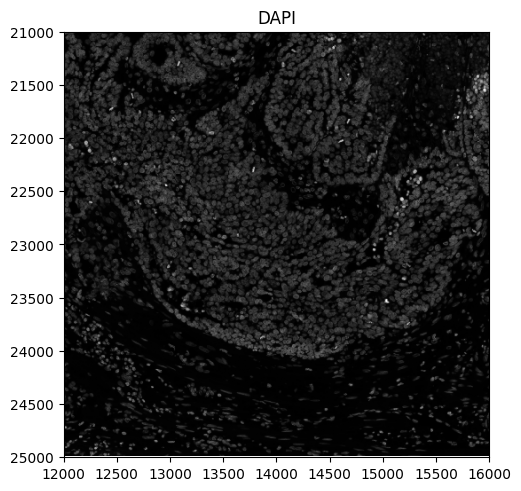

In [68]:
# We can plot the DAPI image using spatialdata-plot
sdata.pl.render_images(
    element="morphology_focus_global",
    channel="DAPI",
    cmap="gray",
).pl.show(
    coordinate_systems="global",
    title="DAPI",
    colorbar=False,
)

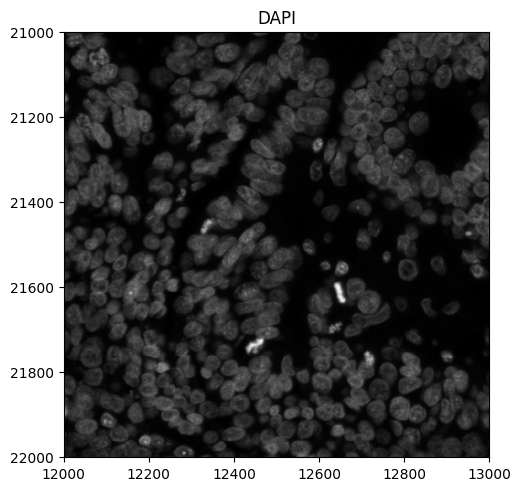

In [69]:
# To plot a crop of the image, we need to first do a bounding box query
min_x = 12000
max_x = 13000
min_y = 21000
max_y = 22000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

# We can plot the DAPI image using spatialdata-plot
sdata_crop.pl.render_images(
    element="morphology_focus_global",
    channel="DAPI",
    cmap="gray",
).pl.show(
    coordinate_systems="global",
    title="DAPI",
    colorbar=False,
)

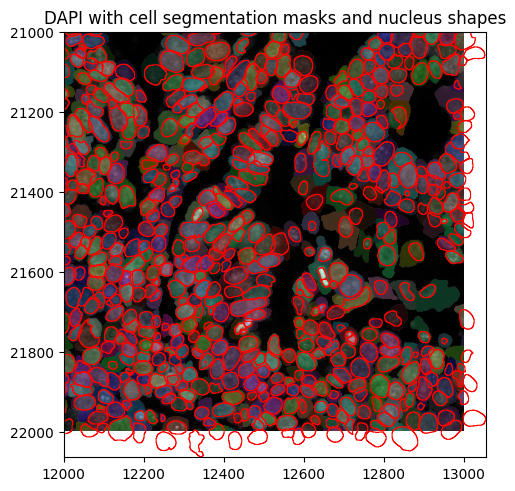

In [70]:
# To create more complex plots, we can chain the render functions
sdata_crop.pl.render_images(
    element="morphology_focus_global",
    channel="DAPI",
    cmap="gray",
).pl.render_labels(element="cell_labels_global", fill_alpha=0.3, contour_px=5, outline_alpha=0).pl.render_shapes(
    element="nucleus_shapes_global",
    fill_alpha=0,
    outline_width=0.8,
    outline_alpha=1,
    outline_color="red",
).pl.show(
    coordinate_systems="global",
    title="DAPI with cell segmentation masks and nucleus shapes",
    colorbar=False,
)


WARNING  render_labels: Converting copy of 'segmentation_method' column to categorical dtype for categorical       
         plotting. Consider converting before plotting.                                                            


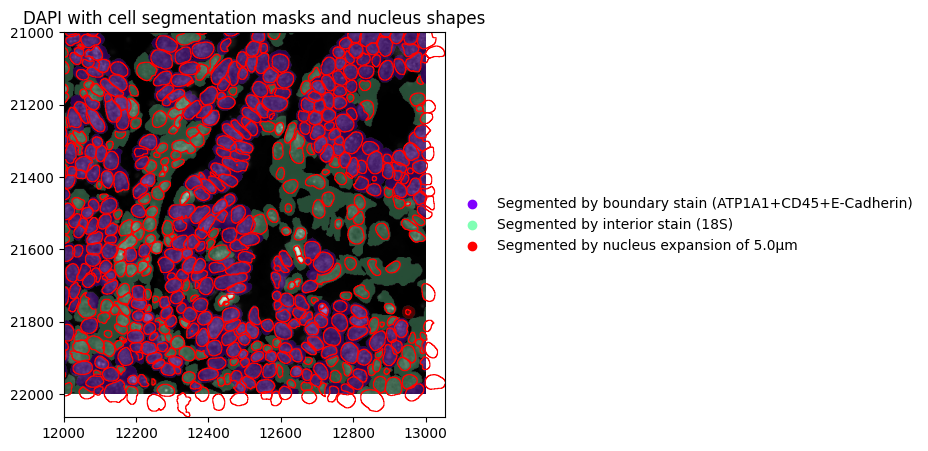

In [71]:
# We can also plot the genes and obs columns from the table layer
sdata_crop.pl.render_images(
    element="morphology_focus_global",
    channel="DAPI",
    cmap="gray",
).pl.render_labels(
    element="cell_labels_global",
    fill_alpha=0.3,
    contour_px=5,
    outline_alpha=0,
    cmap="rainbow",
    color="segmentation_method",
    table_name="table_global",
).pl.render_shapes(
    element="nucleus_shapes_global",
    fill_alpha=0,
    outline_width=0.8,
    outline_alpha=1,
    outline_color="red",
).pl.show(
    coordinate_systems="global",
    title="DAPI with cell segmentation masks and nucleus shapes",
    colorbar=False,
    legend_fontsize=10,
    legend_fontweight="bold",
    legend_loc="right margin",
    figsize=(5, 5),
)

WARNING  render_labels: Converting copy of 'segmentation_method' column to categorical dtype for categorical       
         plotting. Consider converting before plotting.                                                            
Plot saved at: /var/folders/sz/t3tgg4fs4tz9btm0fbqg_tzc0000gn/T/xenium_csc3sftj/test_plot.png


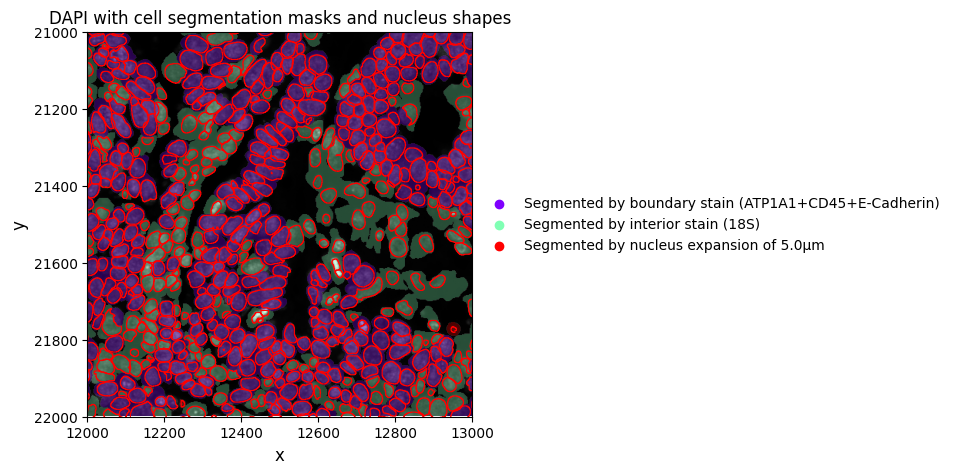

In [72]:
# However, we might want to clean up the plots a bit more, leading to large chunks of code.
min_x = 12000
max_x = 13000
min_y = 21000
max_y = 22000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

fig, ax = plt.subplots(
    figsize=(5, 5)
)  # We create a figure and axis object to have more control over the plot aesthetics.
# fig (Figure) refers to the entire canvas. It can contain one or many Axes (subplots). It controls global properties such as overall size, layout, background, and saving the final image.
# ax (Axes) corresponds to the actual plotting area inside the figure. It contains the x‑axis, y‑axis, titles, points, etc. Each subplot is one Axes object.

title = "DAPI with cell segmentation masks and nucleus shapes"

sdata_crop.pl.render_images(
    element="morphology_focus_global",
    channel="DAPI",
    cmap="gray",
).pl.render_labels(
    element="cell_labels_global",
    fill_alpha=0.3,
    contour_px=2,
    outline_alpha=0,
    cmap="rainbow",
    color="segmentation_method",
    table_name="table_global",
).pl.render_shapes(
    element="nucleus_shapes_global",
    fill_alpha=0,
    outline_width=0.8,
    outline_alpha=1,
    outline_color="red",
).pl.show(
    coordinate_systems="global",
    title=title,
    colorbar=False,
    figsize=(5, 5),
    ax=ax,
    legend_fontsize=10,
    legend_fontweight="bold",
    legend_loc="right margin",
    na_in_legend=True,
)

ax.set_title(title, fontsize=12)  # This allows us to set the title font size
ax.set_xlabel("x", fontsize=12)  # This adds a label to x-axis and sets the font size
ax.set_ylabel("y", fontsize=12)  # This adds a label to y-axis and sets the font size
ax.tick_params(axis="both", which="both", labelsize=10)  # This allows us to set the tick label size

ax.set_xlim(
    min_x, max_x
)  # This limits the axes to the same bounding box as the query, which avoids shapes from a shapes layer breaking the frame.
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()  # Setting the xlim and ylim inverts the axes and this line inverts the yaxis back to the correct orientation for microscopy images.

save_path = os.path.join(output_dir, "test_plot.png")
fig.savefig(
    save_path,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white",
    transparent=False,
)  # This saves the plot to disk

# plt.close(fig) # This closes the figure so it is not displayed in the notebook.

print("Plot saved at:", save_path, flush=True)

#### 3.3.2 Harpy
Harpy has 2 main plotting functions to plot the contents of a SpatialData object: hp.pl.plot_sdata() and hp.pl.plot_sdata_gene(). Note that there are also other plotting functions for more specific use-cases, but we will not look into those here.

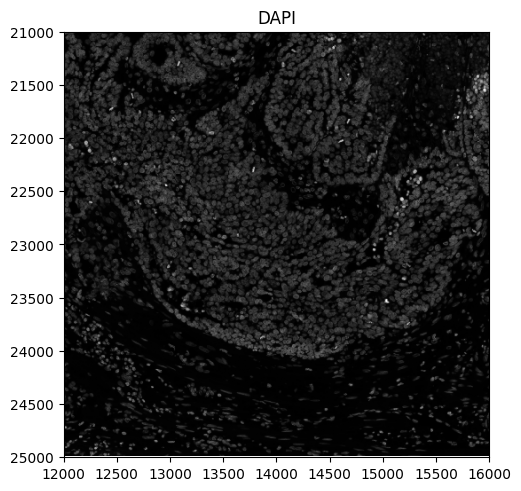

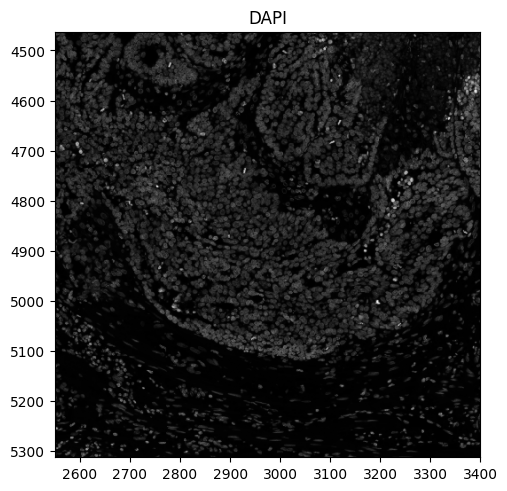

In [73]:
# Plot DAPI image using hp.pl.plot_sdata()
ax = hp.pl.plot_sdata(
    sdata,
    image_name="morphology_focus_global",
    channel="DAPI",
    crd=None,  # Define crop to plot (xmin, xmax, ymin, ymax)
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey"},  # keyword arguments passed on to spatialdata-plot's .pl.render_images()
    show_kwargs={
        "title": "DAPI",
        "colorbar": False,
    },  # keyword arguments passed on to spatialdata-plot's .pl.show()
)

# or in microns:

ax = hp.pl.plot_sdata(
    sdata,
    image_name="morphology_focus_global",
    channel="DAPI",
    crd=None,  # Define crop to plot (xmin, xmax, ymin, ymax)
    to_coordinate_system="global_micron",
    render_images_kwargs={"cmap": "grey"},  # keyword arguments passed on to spatialdata-plot's .pl.render_images()
    show_kwargs={
        "title": "DAPI",
        "colorbar": False,
    },  # keyword arguments passed on to spatialdata-plot's .pl.show()
)

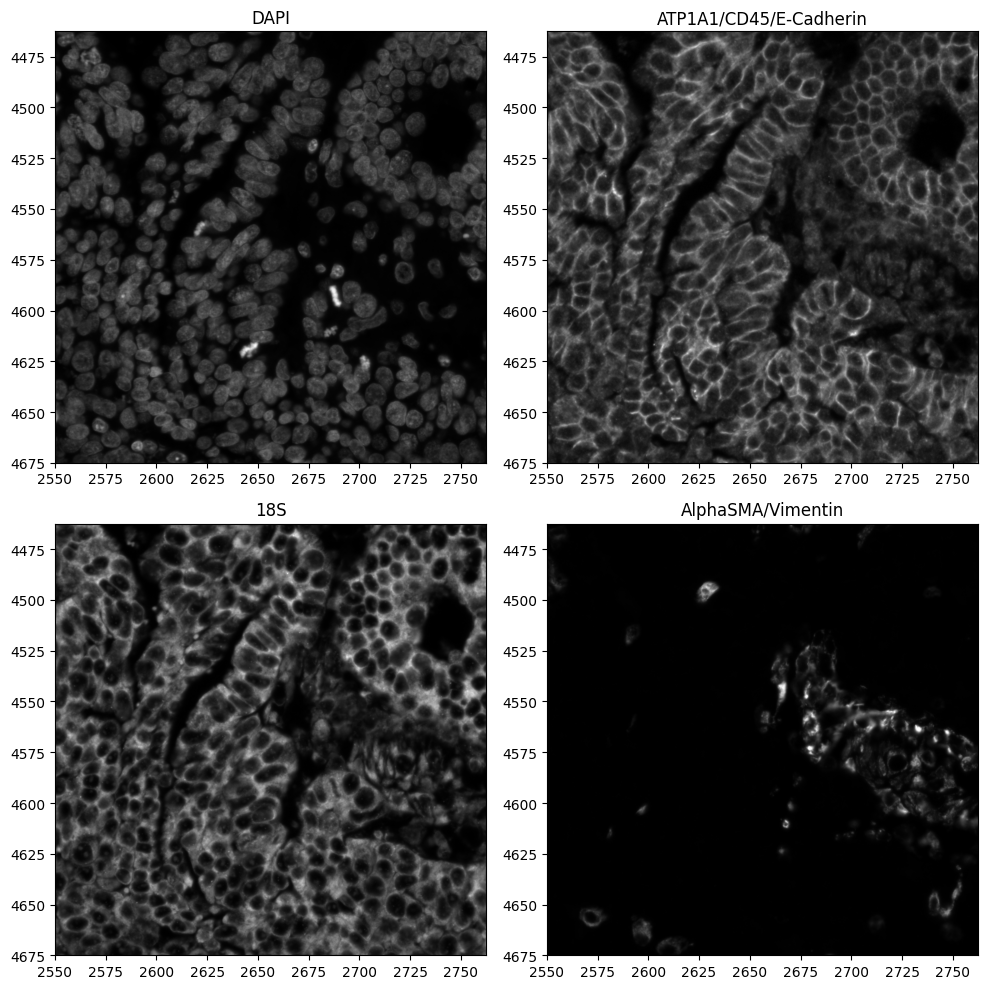

In [74]:
# Plot all channels for a crop of the image
pixel_size = 0.2125  # We need to specify the coordinates in micron if we want to use the micron coordinate system

min_x = 12000 * pixel_size
max_x = 13000 * pixel_size
min_y = 21000 * pixel_size
max_y = 22000 * pixel_size

channels = ["DAPI", "ATP1A1/CD45/E-Cadherin", "18S", "AlphaSMA/Vimentin"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, channel in zip(axes.ravel(), channels):
    ax = hp.pl.plot_sdata(
        sdata,
        image_name="morphology_focus_global",
        channel=channel,
        crd=(
            min_x,
            max_x,
            min_y,
            max_y,
        ),  # Define crop to plot (xmin, xmax, ymin, ymax)
        to_coordinate_system="global_micron",  # We are plotting in the micron coordinates
        render_images_kwargs={"cmap": "grey"},
        show_kwargs={"title": channel, "colorbar": False},
        ax=ax,
    )

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Cell segmentation'}>

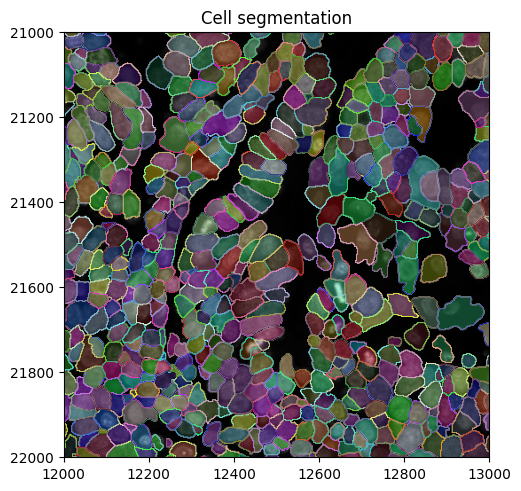

In [75]:
# Plot cell segmentation mask
hp.pl.plot_sdata(
    sdata,
    image_name="morphology_focus_global",
    channel="DAPI",
    labels_name="cell_labels_global",
    crd=(12000, 13000, 21000, 22000),
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 0.4, "contour_px": 3, "outline_alpha": 1},
    show_kwargs={"title": "Cell segmentation", "colorbar": False},
)

2026-06-11 14:05:04.434 | INFO     | harpy.plot._plot_sdata:plot_sdata_genes:540 - Plotting column gene of 'sdata.points[transcripts_global]' as categorical.


<Axes: title={'center': 'Transcripts'}>

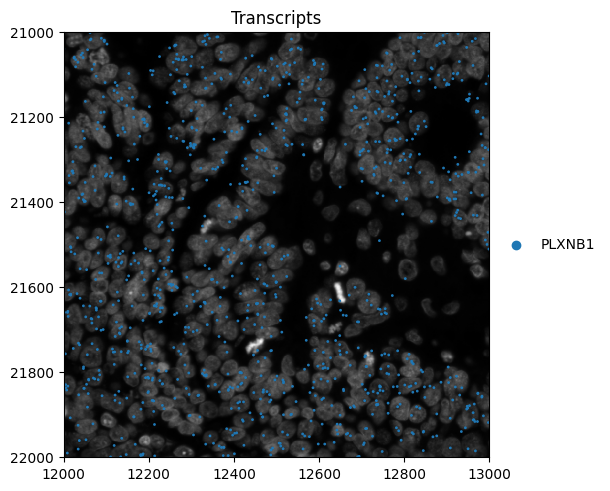

In [76]:
"""
# Note: on current version of spatialdata you can run into issues if the dask dataframe has duplicate indices,
# workaround is to do:
df = sdata.points["transcripts_global"]
attrs = dict(df.attrs)

df = df.reset_index(drop=True)
df.attrs.update(attrs)

sdata.points["transcripts_global"] = df

Fix is on its way (https://github.com/scverse/spatialdata/pull/1129)
"""
# Plot transcripts for a specific gene

hp.pl.plot_sdata_genes(
    sdata,
    image_name="morphology_focus_global",
    channel="DAPI",
    points_name="transcripts_global",
    crd=(12000, 13000, 21000, 22000),
    color="cornflowerblue",
    genes=["PLXNB1"],  # List of genes to plot (if None, all genes will be plotted)
    frac=1,  # We can also randomly subsampling transcripts to speed up plotting
    size=1,
    render_images_kwargs={"cmap": "grey"},
    show_kwargs={"title": "Transcripts", "colorbar": False},
    to_coordinate_system="global",
)